# No-fracture transport control: MRST vs notebook upwind

This copied diagnostic removes the fracture completely and compares the no-fracture MRST/TPFA transport export with the notebook's own explicit upwind finite-volume transport on the same frozen matrix face flux.  The goal is to isolate the base transport implementation before interpreting fracture-coupling effects.


In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

MRST_NOFRACTURE_FILE = pathlib.Path("case3_ecmor/case3_mrst_export_nofrac.mat")
if not MRST_NOFRACTURE_FILE.exists():
    MRST_NOFRACTURE_FILE = pathlib.Path("fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export_nofrac.mat")
if not MRST_NOFRACTURE_FILE.exists():
    raise FileNotFoundError("Could not find case3_mrst_export_nofrac.mat from the notebook or repository root.")

mat = loadmat(MRST_NOFRACTURE_FILE, squeeze_me=True, struct_as_record=False)

NOFRAC_SAVE_FIGURES = True
NOFRAC_OUTDIR = pathlib.Path("result_koppel_martin_case1_no_fracture_transport")
NOFRAC_OUTDIR.mkdir(exist_ok=True)

def _arr(name, dtype=float):
    if name not in mat:
        raise KeyError(f"Missing required MRST field {name!r}")
    return np.asarray(mat[name], dtype=dtype)

def _meta_float(name, default=np.nan):
    if name not in mat:
        return float(default)
    return float(np.asarray(mat[name]).squeeze())

xc_matrix = _arr("xc_matrix", float)
face_neighbors = _arr("face_neighbors", int)
face_flux = _arr("face_flux", float).reshape(-1)
face_centroid = _arr("face_centroid", float)
face_normal = _arr("face_normal", float)
face_len = _arr("face_len", float).reshape(-1)

sw_mrst = {
    "T1": _arr("sw_matrix_t1", float).reshape(-1),
    "T2": _arr("sw_matrix_t2", float).reshape(-1),
}
sw_mrst_matched = {
    "T1": _arr("sw_matrix_t1_matched", float).reshape(-1),
    "T2": _arr("sw_matrix_t2_matched", float).reshape(-1),
}

nx, ny = np.asarray(mat["meta_celldim"], dtype=int).reshape(-1)
physdim = np.asarray(mat["meta_physdim"], dtype=float).reshape(-1)
phi_matrix = _meta_float("meta_phi_matrix", 1.0)
PV_matrix = _meta_float("meta_PV_matrix", phi_matrix * np.prod(physdim))
Q_water = _meta_float("meta_Q_water", np.nan)
CFL = _meta_float("meta_CFL", 0.45)
FPRIME_MAX = _meta_float("meta_FPRIME_MAX", 2.0)
transport_times = {
    "T1": _meta_float("meta_T1"),
    "T2": _meta_float("meta_T2"),
}
transport_pvi = {
    "T1": _meta_float("meta_PVI1"),
    "T2": _meta_float("meta_PVI2"),
}

ncell = xc_matrix.shape[0]
cell_pv = np.full(ncell, PV_matrix / ncell, dtype=float)
print(f"Loaded {MRST_NOFRACTURE_FILE}")
print(f"No-fracture MRST grid: {nx} x {ny}, cells={ncell}, faces={face_flux.size}")
print(f"Q_water={Q_water:.8e}, PV_matrix={PV_matrix:.8e}, CFL={CFL:.3f}")
for key in ("T1", "T2"):
    print(f"  {key}: T={transport_times[key]:.8e}, PVI={transport_pvi[key]:.6f}, MRST Sw=[{sw_mrst[key].min():.3e}, {sw_mrst[key].max():.3e}]")


Loaded case3_ecmor/case3_mrst_export_nofrac.mat
No-fracture MRST grid: 128 x 128, cells=16384, faces=33024
Q_water=3.00000000e+00, PV_matrix=1.00000000e+00, CFL=0.450
  T1: T=3.33333333e-01, PVI=1.000000, MRST Sw=[7.389e-01, 9.928e-01]
  T2: T=3.50000000e-01, PVI=1.050000, MRST Sw=[7.482e-01, 9.931e-01]


In [2]:
# Build the same signed face-connection list as the MRST export script.
# Fout is positive outward from owner; for an interior face it is positive from owner to neighbor.
n1 = face_neighbors[:, 0].astype(int)
n2 = face_neighbors[:, 1].astype(int)
is_internal = (n1 > 0) & (n2 > 0)
is_boundary = ~is_internal

owner_int = n1[is_internal] - 1
neigh_int = n2[is_internal] - 1
F_int = face_flux[is_internal]

owner_b = np.maximum(n1[is_boundary], n2[is_boundary]) - 1
sgn_b = np.ones(np.count_nonzero(is_boundary), dtype=float)
sgn_b[n1[is_boundary] == 0] = -1.0
F_b = face_flux[is_boundary] * sgn_b

RIGHT_BC_S = 1.0
inlet_s_b = np.zeros_like(F_b)
inlet_s_b[np.isclose(face_centroid[is_boundary, 0], physdim[0], atol=1.0e-10)] = RIGHT_BC_S

owner = np.concatenate([owner_int, owner_b]).astype(int)
neigh = np.concatenate([neigh_int, -np.ones_like(owner_b)]).astype(int)
Fout = np.concatenate([F_int, F_b]).astype(float)
inlet_s = np.concatenate([np.zeros_like(F_int), inlet_s_b]).astype(float)
has_neighbor = neigh >= 0
is_boundary_conn = ~has_neighbor

outflow = np.zeros(ncell, dtype=float)
np.add.at(outflow, owner, np.maximum(Fout, 0.0))
np.add.at(outflow, neigh[has_neighbor], np.maximum(-Fout[has_neighbor], 0.0))
active = outflow > 1.0e-30
dt_cfl = CFL * np.min(cell_pv[active] / (FPRIME_MAX * outflow[active]))

print(f"Connection list: internal={owner_int.size}, boundary={owner_b.size}")
print(f"Right-boundary inlet faces={np.count_nonzero(inlet_s_b > 0)}")
print(f"CFL timestep from exported no-fracture flux: dt_CFL={dt_cfl:.8e}")
print(f"Net single-phase boundary flux sum(F_boundary_out)={np.sum(F_b):+.6e}")


Connection list: internal=32512, boundary=512
Right-boundary inlet faces=128
CFL timestep from exported no-fracture flux: dt_CFL=5.85937500e-04
Net single-phase boundary flux sum(F_boundary_out)=+5.080381e-12


In [3]:
def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S**2 / (S**2 + (1.0 - S)**2 + 1.0e-30)


def advance_no_fracture_transport(t_final, dt_scale=1.0, clip=True):
    dt_limit = dt_cfl * float(dt_scale)
    nsteps = max(1, int(np.ceil(float(t_final) / dt_limit)))
    dt = float(t_final) / nsteps
    dt_over_pv = dt / cell_pv

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & is_boundary_conn
    up_cell = np.empty_like(owner)
    up_cell[outward] = owner[outward]
    interior_negative = (~outward) & has_neighbor
    up_cell[interior_negative] = neigh[interior_negative]
    up_cell[incoming_boundary] = owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(inlet_s) * Fout

    S = np.zeros(ncell, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clipped_count = 0
    clip_mass_delta = 0.0

    for _ in range(nsteps):
        w = fractional_flow_bl(S[up_cell]) * Fout
        w[incoming_boundary] = boundary_water_flux[incoming_boundary]

        wb = w[is_boundary_conn]
        cumulative_in += dt * np.sum(np.maximum(-wb, 0.0))
        cumulative_out += dt * np.sum(np.maximum(wb, 0.0))

        div = np.zeros(ncell, dtype=float)
        np.add.at(div, owner, w)
        np.add.at(div, neigh[has_neighbor], -w[has_neighbor])
        S_new = S - dt_over_pv * div
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * cell_pv))
            S = S_clip
        else:
            S = S_new

    mass = float(np.sum(S * cell_pv))
    net = float(cumulative_in - cumulative_out)
    return S, {
        "T": float(t_final),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "dt_scale": float(dt_scale),
        "nsteps": int(nsteps),
        "water_in": float(cumulative_in),
        "water_out": float(cumulative_out),
        "water_net": net,
        "water_mass": mass,
        "water_balance_error": float(mass - net),
        "water_balance_error_pct_in": float(100.0 * (mass - net) / cumulative_in) if cumulative_in > 0 else np.nan,
        "preclip_min": float(preclip_min),
        "preclip_max": float(preclip_max),
        "clip_mass_delta": float(clip_mass_delta),
        "clipped_count": int(clipped_count),
    }


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def maxabs(a, b):
    return float(np.max(np.abs(np.asarray(a) - np.asarray(b))))

NOFRAC_CLIP = True
NOFRAC_DT_SCALES = [1.0, 0.5]

nofrac_results = {}
for scale in NOFRAC_DT_SCALES:
    nofrac_results[scale] = {}
    for key in ("T1", "T2"):
        S, meta = advance_no_fracture_transport(transport_times[key], dt_scale=scale, clip=NOFRAC_CLIP)
        nofrac_results[scale][key] = {"S": S, "meta": meta}

print("No-fracture transport diagnostics")
print("  dt_scale  time       nsteps        dt          RMSE(MRST)    max|e|       balance %in   clip dM")
for scale in NOFRAC_DT_SCALES:
    for key in ("T1", "T2"):
        S = nofrac_results[scale][key]["S"]
        meta = nofrac_results[scale][key]["meta"]
        print(
            f"  {scale:8.3f}  {key:<2} {meta['nsteps']:9d} {meta['dt']:11.4e} "
            f"{rmse(S, sw_mrst[key]):12.4e} {maxabs(S, sw_mrst[key]):10.4e} "
            f"{meta['water_balance_error_pct_in']:12.4e} {meta['clip_mass_delta']:10.3e}"
        )

print("\nMRST explicitTransport vs MRST hand-coded matched export")
for key in ("T1", "T2"):
    print(f"  {key}: RMSE={rmse(sw_mrst_matched[key], sw_mrst[key]):.4e}, max|e|={maxabs(sw_mrst_matched[key], sw_mrst[key]):.4e}")

print("\nNotebook dt refinement, dt vs dt/2")
for key in ("T1", "T2"):
    S1 = nofrac_results[1.0][key]["S"]
    S2 = nofrac_results[0.5][key]["S"]
    print(f"  {key}: RMSE={rmse(S1, S2):.4e}, max|e|={maxabs(S1, S2):.4e}")


No-fracture transport diagnostics
  dt_scale  time       nsteps        dt          RMSE(MRST)    max|e|       balance %in   clip dM
     1.000  T1       569  5.8582e-04   2.5411e-04 4.9243e-04   6.1062e-13  0.000e+00
     1.000  T2       598  5.8528e-04   2.3855e-04 4.2663e-04  -8.3531e-13  0.000e+00
     0.500  T1      1138  2.9291e-04   8.4120e-04 1.6654e-03  -2.4980e-12  0.000e+00
     0.500  T2      1195  2.9289e-04   7.6353e-04 1.3993e-03  -1.6812e-12  0.000e+00

MRST explicitTransport vs MRST hand-coded matched export
  T1: RMSE=2.5411e-04, max|e|=4.9243e-04
  T2: RMSE=2.3855e-04, max|e|=4.2663e-04

Notebook dt refinement, dt vs dt/2
  T1: RMSE=5.8719e-04, max|e|=1.1730e-03
  T2: RMSE=5.2506e-04, max|e|=9.7265e-04


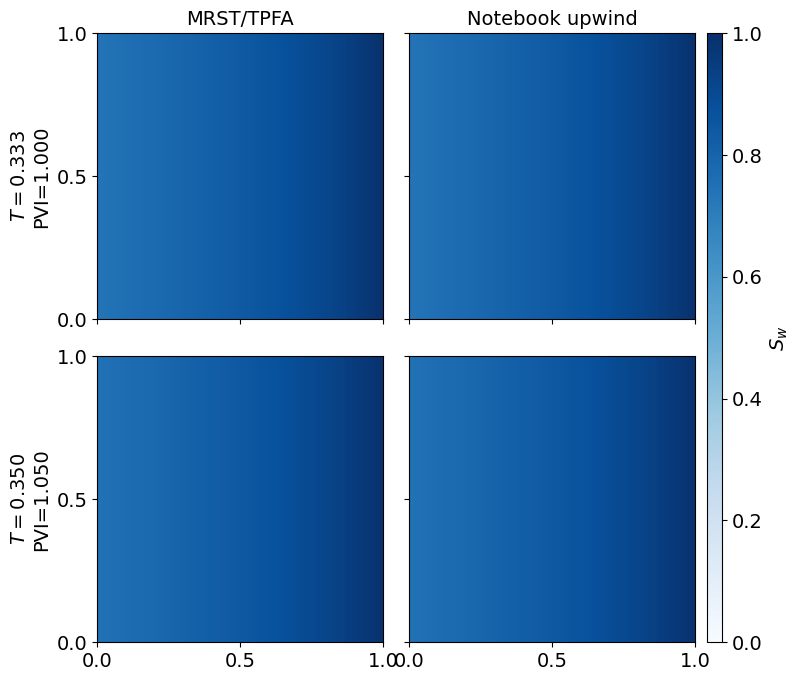

In [4]:
# Plot MRST explicitTransport and the notebook upwind solution using the default CFL timestep.
def cell_field_to_grid(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    dx = physdim[0] / nx
    dy = physdim[1] / ny
    ix = np.rint((xc_matrix[:, 0] - 0.5 * dx) / dx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * dy) / dy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid

x_edges = np.linspace(0.0, physdim[0], nx + 1)
y_edges = np.linspace(0.0, physdim[1], ny + 1)
method_titles = ["MRST/TPFA", "Notebook upwind"]
row_keys = ["T1", "T2"]

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(2, 2, figsize=(7.8, 7.0), squeeze=False)
    pcm = None
    for ir, key in enumerate(row_keys):
        fields = [sw_mrst[key], nofrac_results[1.0][key]["S"]]
        for ic, field in enumerate(fields):
            ax = axes[ir, ic]
            pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(field), cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.set_aspect("equal")
            ax.set_xlim(0.0, physdim[0])
            ax.set_ylim(0.0, physdim[1])
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.grid(False)
            if ir == 0:
                ax.set_title(method_titles[ic])
            if ic == 0:
                ax.set_ylabel(rf"$T={transport_times[key]:.3f}$" + "\n" + rf"PVI={transport_pvi[key]:.3f}")
            else:
                ax.tick_params(labelleft=False)
            if ir == 0:
                ax.tick_params(labelbottom=False)
    fig.subplots_adjust(left=0.11, right=0.88, bottom=0.07, top=0.94, wspace=0.08, hspace=0.13)
    top = axes[0, -1].get_position()
    bottom = axes[-1, -1].get_position()
    cax = fig.add_axes([top.x1 + 0.015, bottom.y0, 0.020, top.y1 - bottom.y0])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$S_w$")
    if NOFRAC_SAVE_FIGURES:
        fig.savefig(NOFRAC_OUTDIR / "nofrac_saturation_mrst_vs_code.png", dpi=300, bbox_inches="tight")
    plt.show()


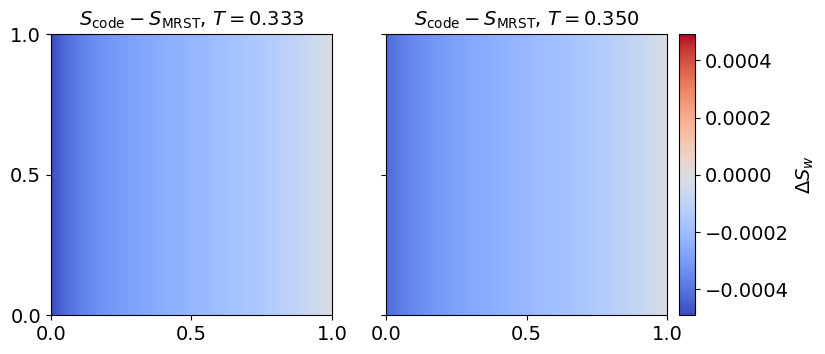

In [5]:
# Difference maps: notebook upwind minus MRST explicitTransport.
err_t1 = nofrac_results[1.0]["T1"]["S"] - sw_mrst["T1"]
err_t2 = nofrac_results[1.0]["T2"]["S"] - sw_mrst["T2"]
err_lim = max(float(np.max(np.abs(err_t1))), float(np.max(np.abs(err_t2))))
err_lim = max(err_lim, 1.0e-12)

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.8), squeeze=False)
    pcm = None
    for ax, key, err in zip(axes.ravel(), ["T1", "T2"], [err_t1, err_t2]):
        pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(err), cmap="coolwarm", vmin=-err_lim, vmax=err_lim, shading="flat")
        ax.set_aspect("equal")
        ax.set_xlim(0.0, physdim[0])
        ax.set_ylim(0.0, physdim[1])
        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.grid(False)
        ax.set_title(rf"$S_{{\rm code}}-S_{{\rm MRST}}$, $T={transport_times[key]:.3f}$")
    axes[0, 1].tick_params(labelleft=False)
    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.14, top=0.88, wspace=0.10)
    pos = axes[0, 1].get_position()
    cax = fig.add_axes([pos.x1 + 0.015, pos.y0, 0.020, pos.height])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$\Delta S_w$")
    if NOFRAC_SAVE_FIGURES:
        fig.savefig(NOFRAC_OUTDIR / "nofrac_saturation_difference_code_minus_mrst.png", dpi=300, bbox_inches="tight")
    plt.show()


In [6]:
# Optional compact table for email/notes.
print("No-fracture control summary")
print("  time    PVI      RMSE(code,MRST)   max|e|       balance residual (% injected)   dt-ref RMSE")
for key in ("T1", "T2"):
    S = nofrac_results[1.0][key]["S"]
    meta = nofrac_results[1.0][key]["meta"]
    S_half = nofrac_results[0.5][key]["S"]
    print(
        f"  {transport_times[key]:.5f} {transport_pvi[key]:7.4f} "
        f"{rmse(S, sw_mrst[key]):16.4e} {maxabs(S, sw_mrst[key]):10.4e} "
        f"{meta['water_balance_error_pct_in']:27.4e} {rmse(S, S_half):12.4e}"
    )


No-fracture control summary
  time    PVI      RMSE(code,MRST)   max|e|       balance residual (% injected)   dt-ref RMSE
  0.33333  1.0000       2.5411e-04 4.9243e-04                  6.1062e-13   5.8719e-04
  0.35000  1.0500       2.3855e-04 4.2663e-04                 -8.3531e-13   5.2506e-04
